In [1]:
ENV["JULIA_NUM_THREADS"] = get(ENV, "JULIA_NUM_THREADS", "4")

using Maranatha


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
ff(x) = sin(x)
bounds = (0.0, π)
dim = 1
ns = [2, 3, 4, 5, 6, 7, 8, 9]
ns .+= 0
rule = :gauss_p4
boundary = :LU_EXEX
err_method = :forwarddiff # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation
fit_terms = 4
nerr_terms = 3
ff_shift = 0
use_threads = true
result_string = "1D"
save_path = "."
write_summary = true
save_file = true

true

In [3]:
run_result = run_Maranatha(
    ff, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method, 
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms, 
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
)

(a = 0.0, b = π, h = [1.5707963267948966, 1.0471975511965976, 0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999543942306, 1.9999999983080423, 1.999999999833522, 1.9999999999722917, 1.9999999999935836, 1.9999999999981357, 1.9999999999993603, 1.9999999999997509], err = NamedTuple[(ks = [8, 10, 12], coeffs = [1.124788539770296e-9, 1.4753719807192386e-10, 3.815912407242014e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787330988e-8, -2.119435374676256e-8, 1.3525608060986144e-9], total = 4.5644404932645934e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099521367e-9, 5.728022157904421e-10, 5.0364674597331475e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.5551694343111364e-9, -9.51304359599064e-10, 9.172718506231512e-11], total = 1.6955922597743876e-9, center = 1.5707963267948966, h = 1.0471975511965976), (ks = [8, 10, 12], coeffs = [2.24957708158

In [4]:
fit_result = least_chi_square_fit(
    run_result.a,
    run_result.b,
    run_result.h,
    run_result.avg,
    run_result.err,
    run_result.rule,
    run_result.boundary;
    nterms=fit_terms,
    ff_shift=ff_shift,
    nerr_terms=nerr_terms
)

[2026-03-07 12:01:19.773] residual ks (backend) = [8, 9, 10, 11], fit powers (h^p), ff_shift=0 = [8, 9, 10]


(estimate = 2.0, error_estimate = 3.923177387241463e-13, params = [2.0, -1.1253742895294865e-9, 3.2472580715607572e-12, -4.380066890856665e-11], param_errors = [3.923177387241463e-13, 3.397407643062535e-9, 7.858548925199711e-9, 3.871043229710997e-9], cov = [1.5391320811762756e-25 -1.0369248085828976e-21 2.161122556815393e-21 -9.777456172220411e-22; -1.036924808582897e-21 1.1542378693139727e-17 -2.6169248282759422e-17 1.242118408523313e-17; 2.1611225568153894e-21 -2.616924828275939e-17 6.175679120975755e-17 -3.00256677481518e-17; -9.777456172220383e-22 1.2421184085233105e-17 -3.002566774815178e-17 1.4984975686291343e-17], powers = [0, 8, 9, 10], chisq = 3.966941827231755e-6, redchisq = 9.917354568079388e-7, dof = 4)

In [5]:
print_fit_result(fit_result)

[2026-03-07 12:01:21.822]            λ_0 = 2.00000000000000(39)
[2026-03-07 12:01:21.823]            λ_1 = -0.0000000011(34) *
[2026-03-07 12:01:21.823]            λ_2 = 0.0000000000(79) *
[2026-03-07 12:01:21.823]            λ_3 = -0.0000000000(39) *
[2026-03-07 12:01:21.823] 
[2026-03-07 12:01:21.823] Chi^2 / d.o.f. = 3.966941827232e-06 / 4 = 9.917354568079e-07
[2026-03-07 12:01:21.824] Result (h→0)   = 2.00000000000000(39)
[2026-03-07 12:01:21.824] 


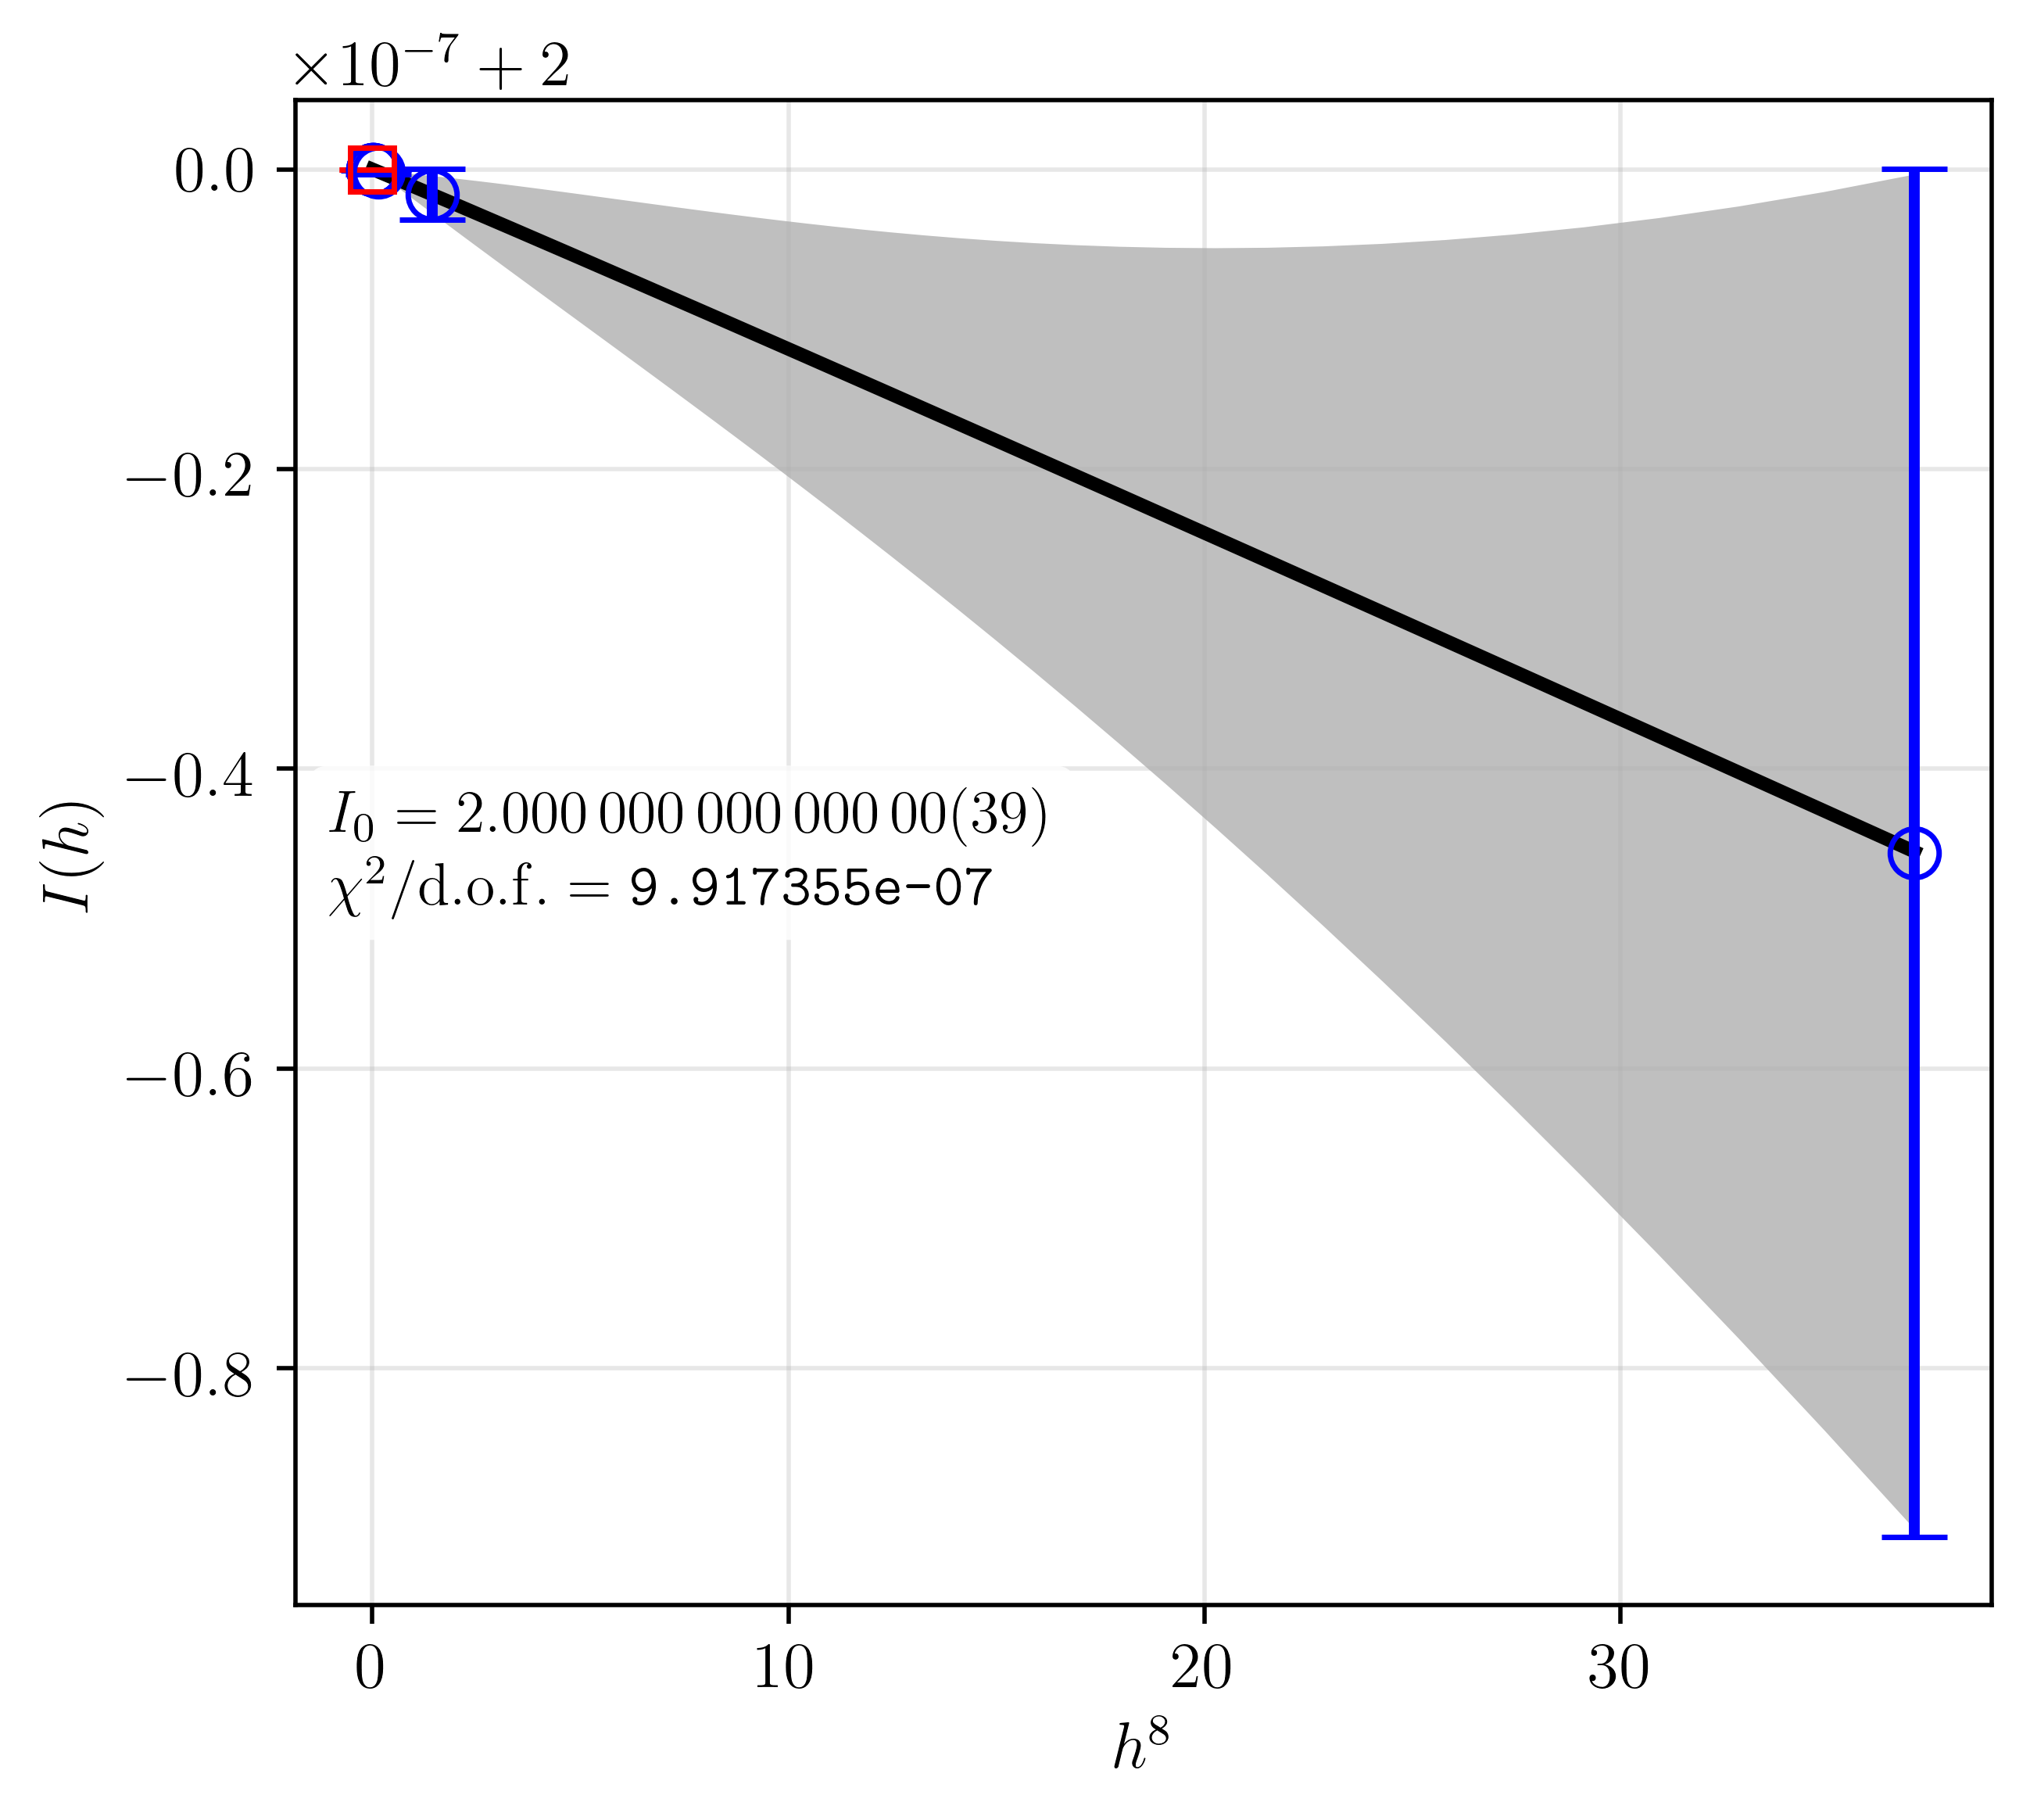

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_1D_gauss_p4_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_1D_gauss_p4_LU_EXEX_reldiff-crop.pdf'.


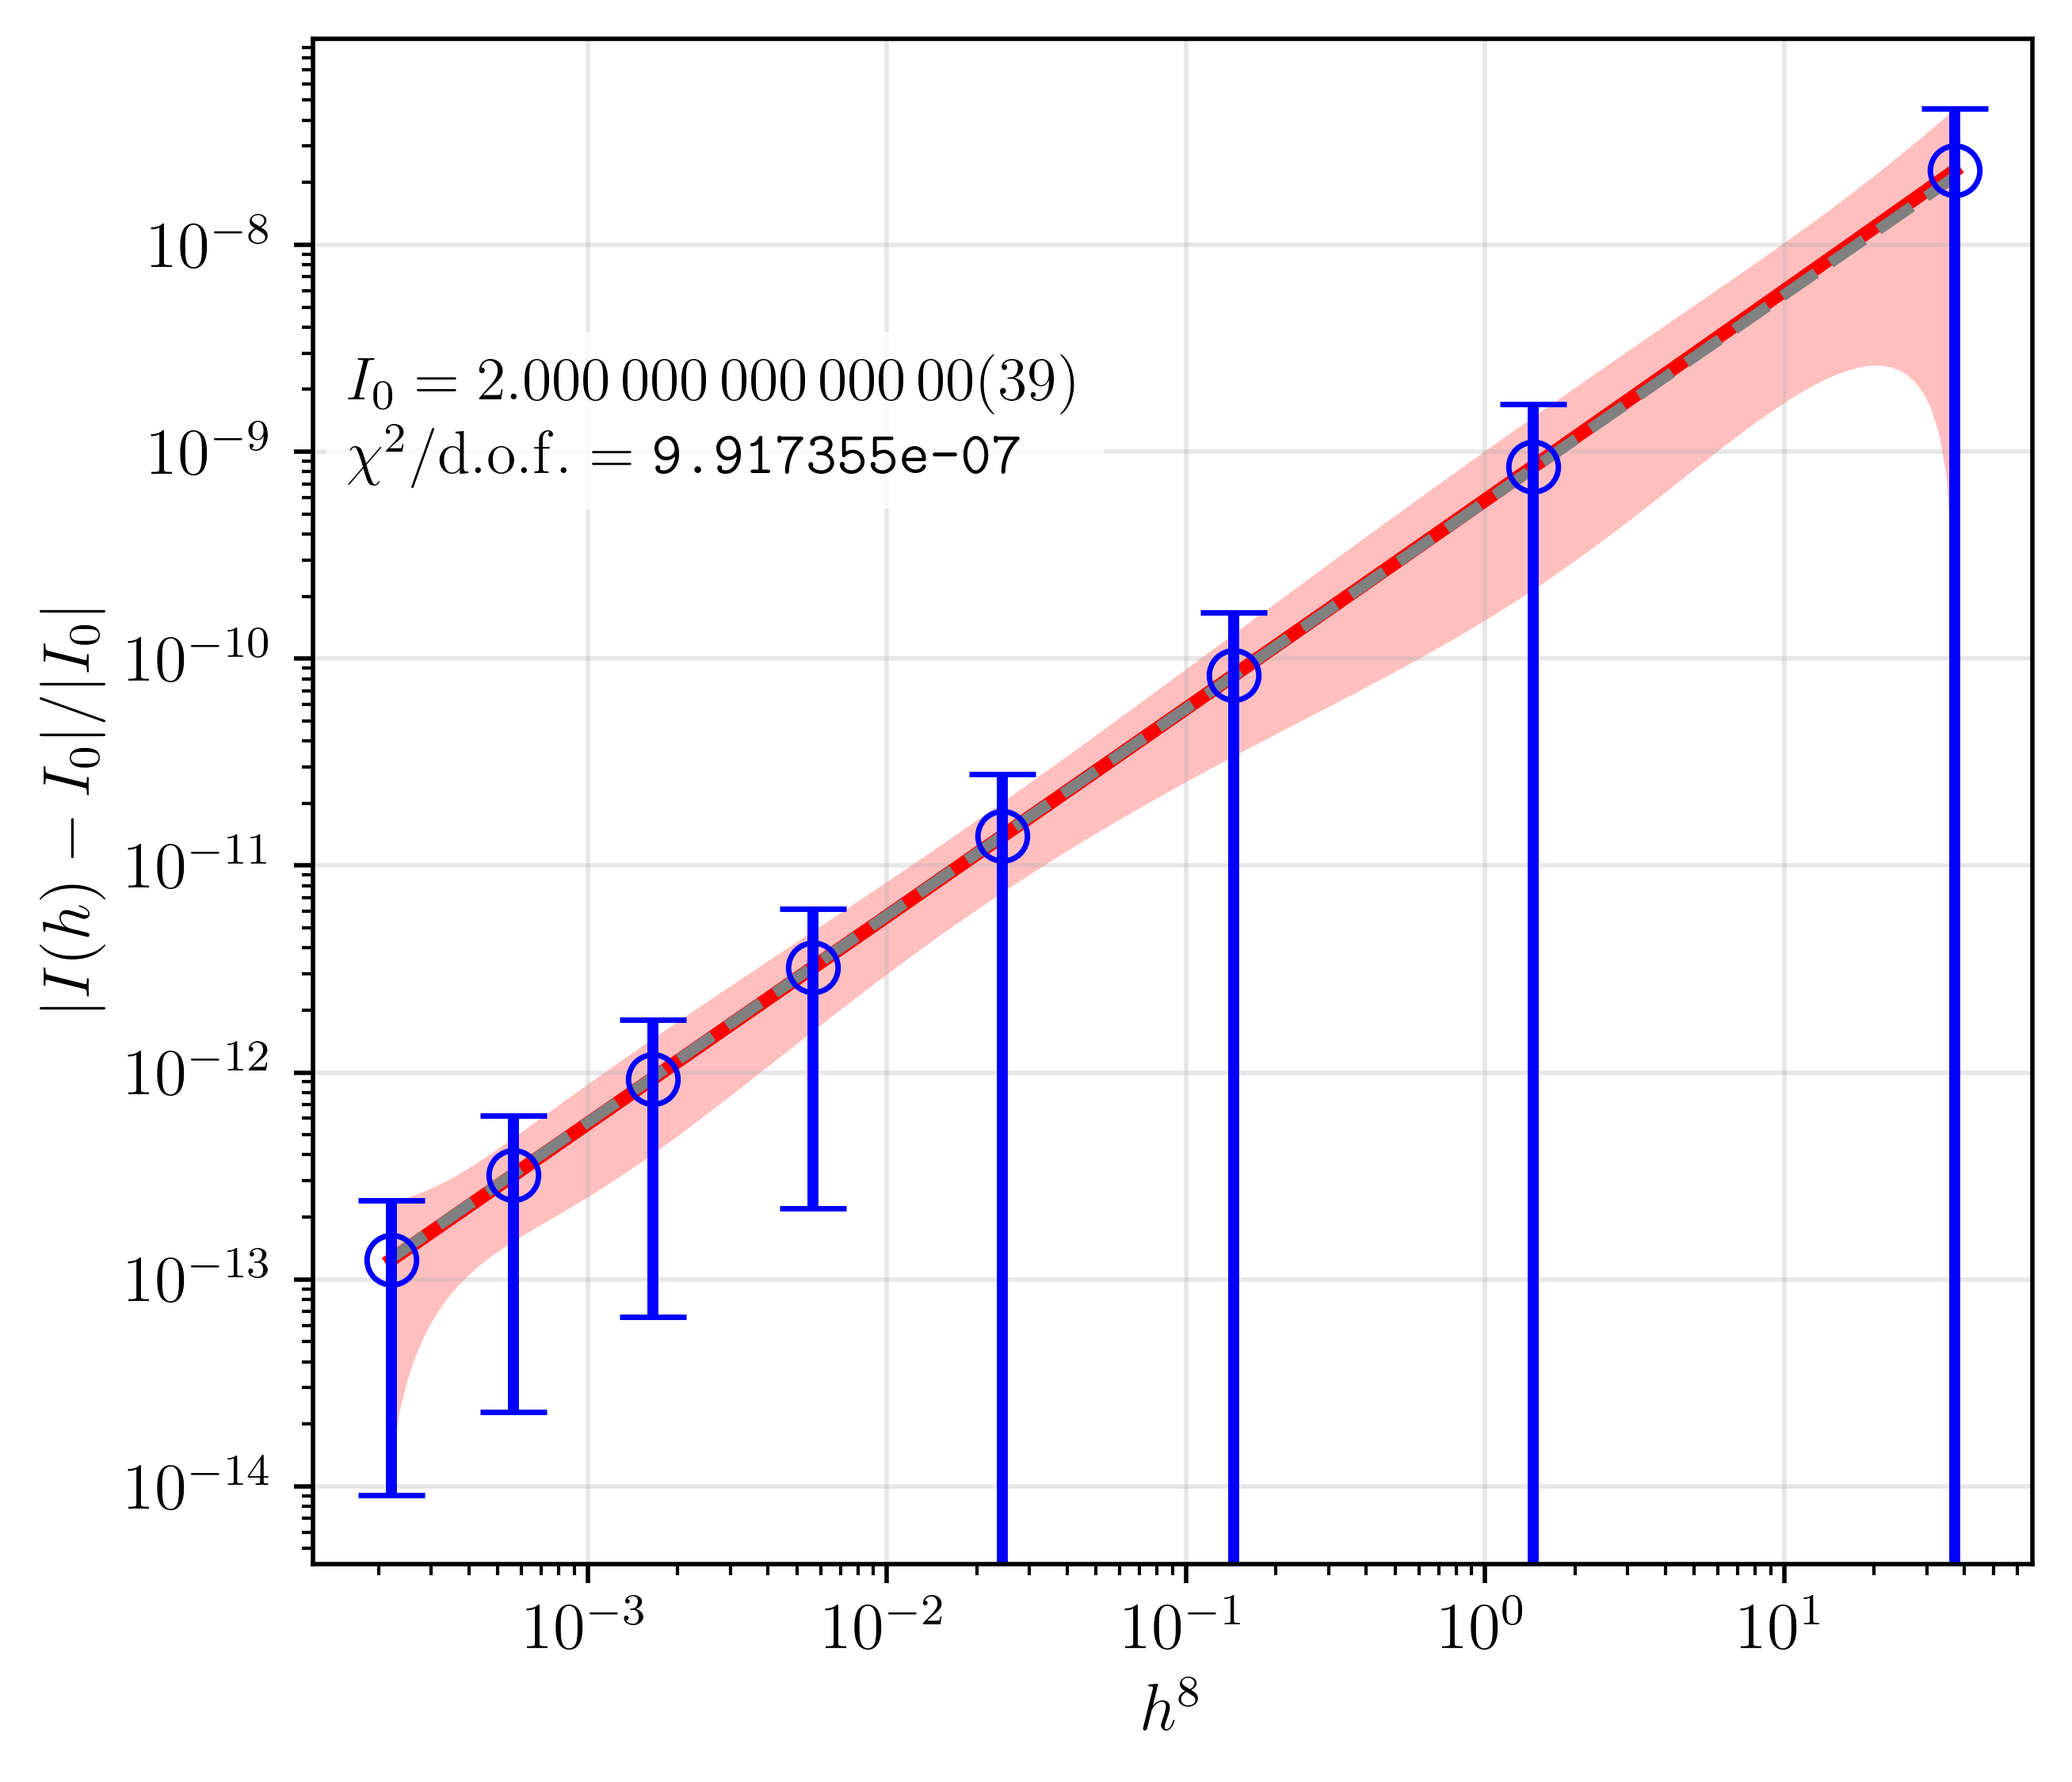

In [6]:
plot_convergence_result(
    bounds..., 
    result_string, 
    run_result.h, 
    run_result.avg, 
    run_result.err, 
    fit_result; 
    rule=rule, 
    boundary=boundary,
    save_file=save_file
)

In [7]:
save_jld2_path = joinpath(
    save_path,
    "result_$(result_string)_$(rule)_$(boundary)_N_$(ns[1])_N_$(ns[end]).jld2"
)

run_result2 = load_datapoint_results(save_jld2_path)

(a = 0.0, b = 3.141592653589793, h = [1.5707963267948966, 1.0471975511965976, 0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999543942306, 1.9999999983080423, 1.999999999833522, 1.9999999999722917, 1.9999999999935836, 1.9999999999981357, 1.9999999999993603, 1.9999999999997509], err = [(ks = [8, 10, 12], coeffs = [1.124788539770296e-9, 1.4753719807192386e-10, 3.815912407242014e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787330988e-8, -2.119435374676256e-8, 1.3525608060986144e-9], total = 4.5644404932645934e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099521367e-9, 5.728022157904421e-10, 5.0364674597331475e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.5551694343111364e-9, -9.51304359599064e-10, 9.172718506231512e-11], total = 1.6955922597743876e-9, center = 1.5707963267948966, h = 1.0471975511965976), (ks = [8, 10, 12], coeffs = [2.24957

In [8]:
fit_result2 = least_chi_square_fit(
    run_result2.a,
    run_result2.b,
    run_result2.h,
    run_result2.avg,
    run_result2.err,
    run_result2.rule,
    run_result2.boundary;
    nterms=fit_terms,
    ff_shift=ff_shift,
    nerr_terms=2
)

[2026-03-07 12:01:33.358] residual ks (backend) = [8, 9, 10, 11], fit powers (h^p), ff_shift=0 = [8, 9, 10]


(estimate = 2.0000000000000004, error_estimate = 5.530451179166816e-13, params = [2.0000000000000004, -1.1251766839566352e-9, 2.6649727260020853e-12, -4.3394617082949615e-11], param_errors = [5.530451179166816e-13, 3.958192062800013e-9, 8.688363170372102e-9, 4.160496207974064e-9], cov = [3.0585890245147625e-25 -1.5753078120169015e-21 3.18450785374167e-21 -1.417667998142163e-21; -1.5753078120168987e-21 1.5667284406013018e-17 -3.3802051540584306e-17 1.5650551049730377e-17; 3.1845078537416632e-21 -3.380205154058427e-17 7.548765458027838e-17 -3.572742780040503e-17; -1.4176679981421587e-21 1.5650551049730355e-17 -3.5727427800405016e-17 1.7309728696566566e-17], powers = [0, 8, 9, 10], chisq = 7.379395600367427e-6, redchisq = 1.8448489000918567e-6, dof = 4)

In [9]:
print_fit_result(fit_result2)

[2026-03-07 12:01:33.378]            λ_0 = 2.00000000000000(55)
[2026-03-07 12:01:33.378]            λ_1 = -0.0000000011(40) *
[2026-03-07 12:01:33.378]            λ_2 = 0.0000000000(87) *
[2026-03-07 12:01:33.379]            λ_3 = -0.0000000000(42) *
[2026-03-07 12:01:33.379] 
[2026-03-07 12:01:33.379] Chi^2 / d.o.f. = 7.379395600367e-06 / 4 = 1.844848900092e-06
[2026-03-07 12:01:33.379] Result (h→0)   = 2.00000000000000(55)
[2026-03-07 12:01:33.379] 


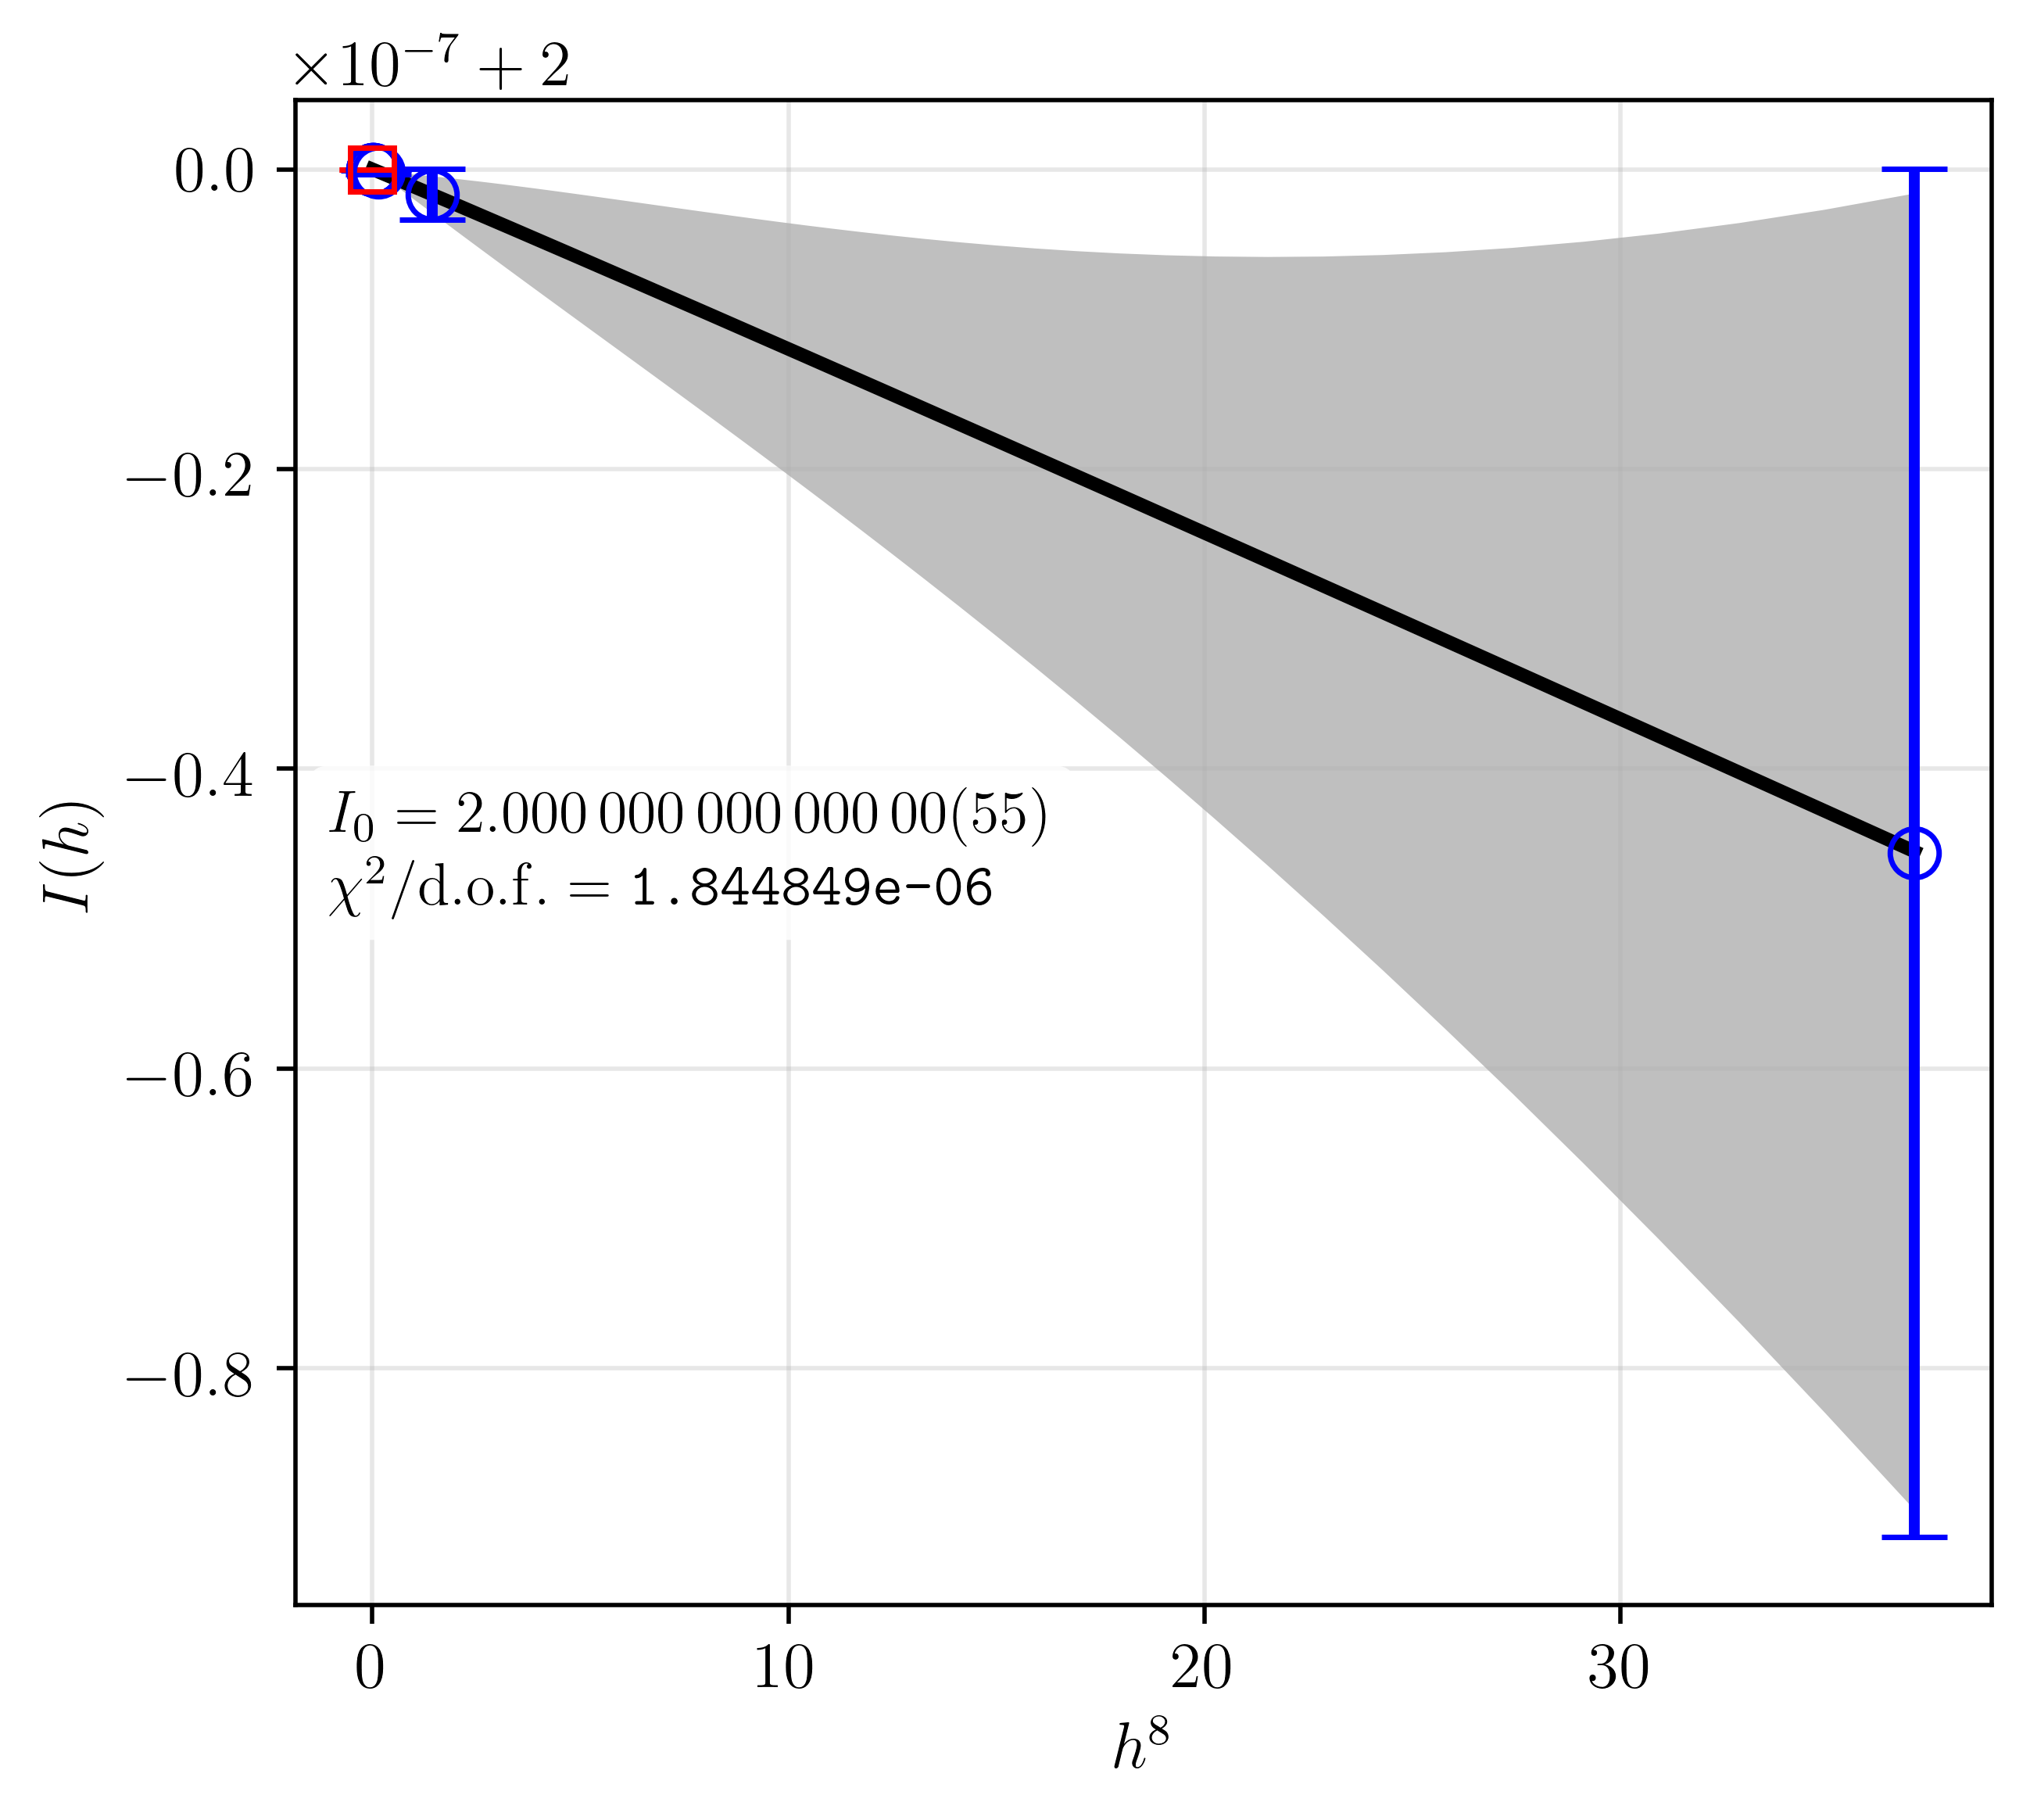

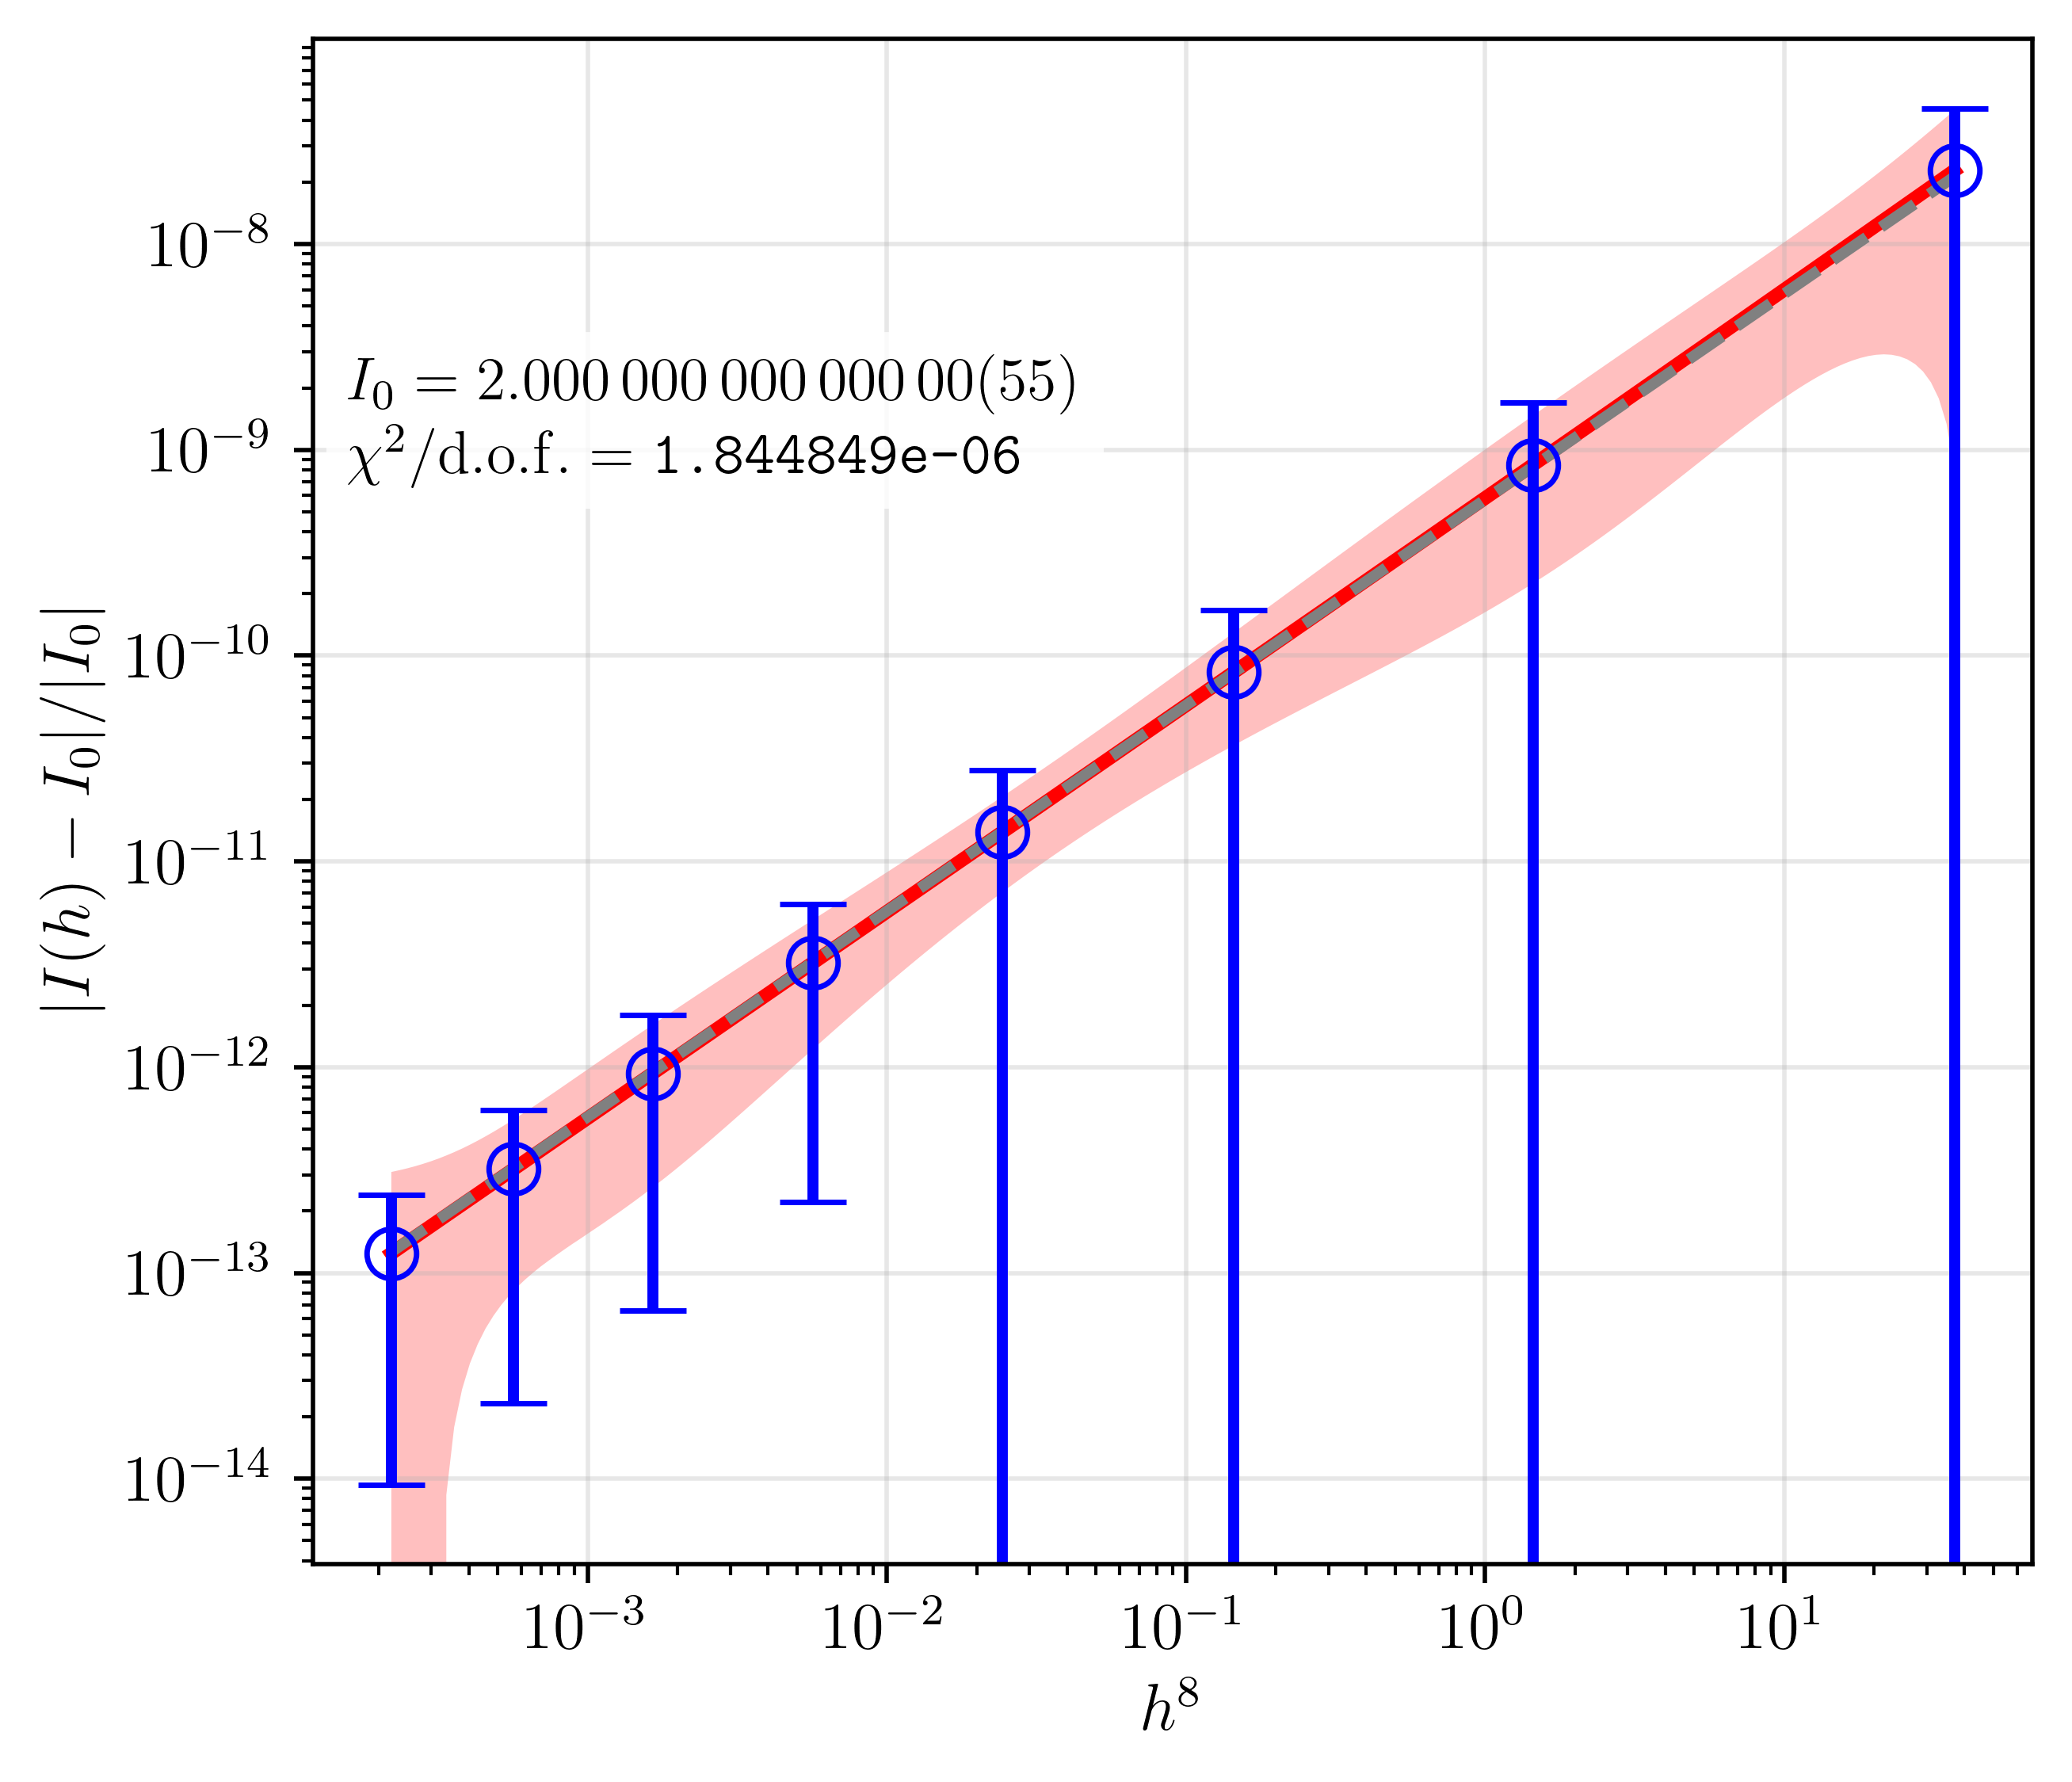

In [10]:
plot_convergence_result(
    bounds..., 
    result_string, 
    run_result2.h, 
    run_result2.avg, 
    run_result2.err, 
    fit_result2; 
    rule=rule, 
    boundary=boundary,
    save_file=false
)